### Requirements

In [1]:
!pip -q install -U datasets tokenizers tqdm transformers accelerate datasets


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, math, time, json, random
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader, Dataset

from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.normalizers import NFKC
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.processors import TemplateProcessing

from transformers import PreTrainedTokenizerFast
from transformers import get_cosine_schedule_with_warmup

from accelerate import Accelerator
import itertools

c:\Users\mouad\VSCode_Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("GPU" if torch.cuda.is_available() else "CPU")

CPU


- We will load the TinyStories dataset that will be using as our training data available on HuggingFace, which consists of a number of synthetic small stories that a typical 3-year-old child would understand, which is in general a very **restricted and small** vocabulary.

In [4]:
TRAIN_EXAMPLES = 50_000
VAL_EXAMPLES = 2_000
train_ds = load_dataset("roneneldan/TinyStories", split=f"train[:{TRAIN_EXAMPLES}]")
val_ds = load_dataset("roneneldan/TinyStories", split=f"validation[:{VAL_EXAMPLES}]")

c:\Users\mouad\VSCode_Projects\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mouad\.cache\huggingface\hub\datasets--roneneldan--TinyStories. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating validation split: 100%|██████████| 21990/21990 [00:00<00:00, 533417.84 examples/s]


In [8]:
train_ds, val_ds, train_ds[0]["text"]

(Dataset({
     features: ['text'],
     num_rows: 50000
 }),
 Dataset({
     features: ['text'],
     num_rows: 2000
 }),
 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.')

In [9]:
a = train_ds[0]["text"].strip()
a

'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'

In [10]:
# this is the size of the TRAIN_EXAMPLEs & VAL_EXAMPLES raw, i.e how much it will take in memory
print(f"{train_ds.data.nbytes  * 1e-6:.2f} in MB")
print(f"{val_ds.data.nbytes  * 1e-6:.2f} in MB")

44.82 in MB
1.60 in MB


In [11]:
# this is probably the size of the whole data maybe not
print(f"{train_ds.info.splits['train'].num_bytes  * 1e-6:.2f} in MB")
print(f"{val_ds.info.splits['validation'].num_bytes  * 1e-6:.2f} in MB")

1911.42 in MB
19.31 in MB


In [12]:
# this is likely the size of the Arrow map style of data in RAM not the actual datasize on disk
print(f"{train_ds.info.dataset_size  * 1e-6:.2f} in MB")
print(f"{val_ds.info.dataset_size  * 1e-6:.2f} in MB")

1930.73 in MB
1930.73 in MB


## Train a Tokenizer

- We will start by training a tokenizer from scratch on this dataset instead of using a pretrained one, we will for this use the different components provided by hugging face library `tokenizers`.

We start by defining a custom normalizer, which allows to make text more cleaner, here will use Unicode normalization form,
the NFKC (normalization form Compatibility Decomposition followed by canonical composition) so that the same characters that are
visually different will be represented by the same token instead of using different tokens and making the vocab size larger.

for our dataset, the normalization step is unnecessary since it mainly contains the ASCII chars and some punctuations


In [13]:
normalizer = NFKC()
normalizer.normalize_str("ℌ𝔢𝔩𝔩𝔬")

'Hello'

Pre-tokenization is the act of splitting a text into smaller objects that give an upper bound to what your tokens will be at the end of training, for example on whitespaces to avoid getting at the end tokens that larger than one word (like "it is" that appears frequently)

In [14]:
# we use here ByteLevel, which essentially splits all characters to bytes, (using UTF-8) and so then we are only allowed to represent 256 possible characters
# and its consequence, is that we don't need to use the unknown special token as every token can be encoded in one byte
pre_tokenizer = ByteLevel(add_prefix_space=False) # to prevent the first word to have a space like ĠHello
pre_tokenizer.pre_tokenize_str("Hello my friend, how are you?")
# Ġ represents the space character

[('Hello', (0, 5)),
 ('Ġmy', (5, 8)),
 ('Ġfriend', (8, 15)),
 (',', (15, 16)),
 ('Ġhow', (16, 20)),
 ('Ġare', (20, 24)),
 ('Ġyou', (24, 28)),
 ('?', (28, 29))]

In [15]:
VOCAB_SIZE = 8000
TOKENIZER_TRAIN_EXAMPLES = 30_000
SPECIAL_TOKENS = [
    "[PAD]", "[BOS]", "[EOS]", "[MASK]","<|user|>", "<|assistant|>", "<|system|>", "<|end|>",
]

tokenizer = Tokenizer(BPE())
tokenizer.normalizer = normalizer
tokenizer.pre_tokenizer = pre_tokenizer

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    min_frequency=2,
    special_tokens=SPECIAL_TOKENS,
)

# i use here a generator in order to train my tokenizer, and i format using the template given on the fly, instead of creating a whole dataset in memory
def tokenizer_training_generator(ds, n_examples):
    for i in range(min(n_examples, len(ds))):
        story = ds[i]["text"].strip()
        yield f"<|user|>\nWrite a short story.\n<|assistant|>\n{story}\n<|end|>\n"

tokenizer.train_from_iterator(
    tokenizer_training_generator(train_ds, TOKENIZER_TRAIN_EXAMPLES),
    trainer=trainer,
    length=min(TOKENIZER_TRAIN_EXAMPLES, len(train_ds))
)


In [16]:
bos_id = tokenizer.token_to_id("[BOS]")
eos_id = tokenizer.token_to_id("[EOS]")

tokenizer.post_processor = TemplateProcessing(
    single="[BOS] $A [EOS]",
    special_tokens=[("[BOS]", bos_id), ("[EOS]", eos_id)],
)
tokenizer.decoder = ByteLevelDecoder()
print("Vocab size:", tokenizer.get_vocab_size())


Vocab size: 8000


In [17]:
TOKENIZER_DIR = "tiny_stories_tokenizer_from_scratch"
os.makedirs(TOKENIZER_DIR, exist_ok=True)
TOKENIZER_FILE = os.path.join(TOKENIZER_DIR, "tokenizer.json")
tokenizer.save(TOKENIZER_FILE)

After saving our custom tokenizer, we can simply load it and use it on an example

In [18]:
hf_tokenizer = PreTrainedTokenizerFast(tokenizer_file=TOKENIZER_FILE)

hf_tokenizer.pad_token  = "[PAD]"
hf_tokenizer.bos_token  = "[BOS]"
hf_tokenizer.eos_token  = "[EOS]"
hf_tokenizer.mask_token = "[MASK]"

hf_tokenizer.add_special_tokens({
    "additional_special_tokens": ["<|user|>", "<|assistant|>", "<|system|>", "<|end|>"]
})

PAD_ID  = hf_tokenizer.pad_token_id
MASK_ID = hf_tokenizer.mask_token_id
BOS_ID  = hf_tokenizer.bos_token_id
EOS_ID  = hf_tokenizer.eos_token_id

print("PAD_ID:", PAD_ID, "MASK_ID:", MASK_ID, "BOS_ID:", BOS_ID, "EOS_ID:", EOS_ID)
print("Example encoding:", hf_tokenizer.encode("Hello world!"))

PAD_ID: 0 MASK_ID: 3 BOS_ID: 1 EOS_ID: 2
Example encoding: [1, 1262, 1109, 8, 2]


In [19]:
OUT_DIR = "checkpoints/final"
os.makedirs(OUT_DIR, exist_ok=True)

hf_tokenizer.save_pretrained(os.path.join(OUT_DIR, "tokenizer"))

('checkpoints/final/tokenizer/tokenizer_config.json',
 'checkpoints/final/tokenizer/tokenizer.json')

In [20]:
len(hf_tokenizer)

8000

## Build the Diffusion Language Model

- Here we start by making some changes to the classical language model pipeline based of the transformer architecture

  *   In addition to the input embeddings and the positional embedding, we also add a **time-step embedding** as well (diffusion step $t$)
  *   the mask token `[MASK]` will represent the noise that will be added gradually to the input sequence at each time step $t$ following a noise scheduler.
  *   We replace the Causal Attention mask by a bi-directional attention one to use tokens before and after the masked when computing the attention scores of the sequence.
  *   The final downastream task will be to the predict at each step to predict **only the masked tokens** instead of next token objective.

In [53]:
class DiffusionTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.time_emb = nn.Embedding(cfg["diffusion_steps"] + 1, cfg["emb_dim"])
        self.drop = nn.Dropout(cfg["dropout"])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg["emb_dim"],
            nhead=cfg["n_heads"],
            dim_feedforward=cfg["d_ff"],
            dropout=cfg["dropout"],
            activation="gelu",
            batch_first=True,
            norm_first=False
        )

        self.encoder = nn.TransformerEncoder(encoder_layer , num_layers=cfg["n_layers"])
        self.final_norm = nn.LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

        # Tie weights (optional; common in LMs)
        self.out_head.weight = self.tok_emb.weight

    def forward(self, input_ids, timesteps, attention_mask=None):
        # input_ids of size [batch_size, seq_length]
        # timesteps of size [batch_size] integer diffusion step in {1, 2, ...T}
        batch_size, seq_length = input_ids.shape

        tok_embeds = self.tok_emb(input_ids)
        pos_embeds = self.pos_emb(torch.arange(seq_length, device=input_ids.device))
        x = tok_embeds + pos_embeds # [batch_size, seq_length, emb_dim] emb_dim = d_model

        # NEW
        t_emb = self.time_emb(timesteps) # [batch_size, emb_dim]
        t_emb = t_emb.unsqueeze(1) # [batch_size, 1, emb_dim] to allow broadcasting later
        x = x + t_emb # [batch_size, seq_length, emb_dim]

        x = self.drop(x)

        if attention_mask is None:
            src_key_padding_mask = None
        else:
            src_key_padding_mask = ~attention_mask  # invert: True = PAD tokens which will be ignored

        x = self.encoder(x, is_causal=False, src_key_padding_mask=src_key_padding_mask) # this is by default False the causal attention mask
        x = self.final_norm(x)
        logits = self.out_head(x) # [batch_size, seq_length, vocab_size]

        return logits

In [23]:
cfg = {
    "vocab_size": len(hf_tokenizer),
    "context_length": 256,
    "emb_dim": 384,
    "n_layers": 6,
    "n_heads": 6,
    "d_ff": 1536, # 4*emb_dim
    "dropout": 0.1,
    "diffusion_steps": 64
}
model = DiffusionTransformer(cfg)

# compute the number of params
number_params = sum(p.numel() for p in model.parameters())
print(f"{number_params:,} params")


13,842,816 params


## Create Dataset for Training

- We first start by preparing training and validation samples of the same length `seq_length` or `context_length`.

In [24]:
class TokenBlockDataset(Dataset):
      def __init__(self, ds, tokenizer, seq_length, stride):
          self.input_ids = []

          # formatting
          token_ids = []
          for text in ds["text"]:
              formatted = (
                  f"<|user|>\nWrite a short story.\n"
                  f"<|assistant|>\n{text.strip()}\n<|end|>\n"
              )

              token_ids.extend(tokenizer.encode(formatted))

          for i in range(0, len(token_ids) - seq_length, stride):
              input_chunk = token_ids[i:i + seq_length]
              self.input_ids.append(torch.tensor(input_chunk))

          del token_ids
      def __len__(self):
          return len(self.input_ids)

      def __getitem__(self, idx):
          return self.input_ids[idx]

In [25]:
train_dataset = TokenBlockDataset(train_ds,
                                  hf_tokenizer,
                                  cfg["context_length"],
                                  cfg["context_length"])

In [26]:
train_dataset[1]

tensor([  19, 7963,  486,  580,  119, 1335, 1403,  121,  313,  122,  224,  204,
         319,   19, 7963, 1754,  758,  119,  521,  121,  999,  119, 1335, 1403,
         207,  307,   19,  175,  727,  121, 7981,  213, 2735,   19,  104,  104,
        2517,  463,  597,  204,  119, 4139, 1335,  352,  215,   19,  807,  162,
         140,  264,  122,  310,  453,   17, 7963,  568,  135, 1243,  551, 4490,
          19,  175,  335,  122,  119, 4490,  972,  121,  481,  551, 2062, 4490,
          19, 1324,   17, 7963,  140, 1127,  122,  310,  831,  121,  224,  448,
         119,  874,  215,   19,  696, 7963,  747, 1206,  933,  902,   19,  104,
           7,  104,    2,    1,    4,  104,  244,  115,  242,  233,   19,  104,
           5,  104,  290,  215,   17,  115,  265,  937,  362, 3305,  140, 2000,
         955,  119, 2584,   19,  175,  281,  115,  269, 2484,  121,  313,  122,
         195,  346,   19,  194, 1627,   17,  199, 1006, 3305,   19, 1103,  211,
         252,  122,  224,  353,  384,  1

In [27]:
BATCH_SIZE = 32
def collate_fn(batch):
    input_ids = torch.stack(batch, dim=0)  # each input_ids will be a tensor of size [batch_size, seq_length]
    attention_mask = (input_ids != PAD_ID) # it will probably be ALWAYS true since all samples are of same length so no padding except maybe the last one
    return {"input_ids": input_ids, "attention_mask": attention_mask}

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

In [28]:
batch_example = next(iter(train_loader))
batch_example

{'input_ids': tensor([[   1,    4,  104,  ...,  220,  302, 4139],
         [  19, 7963,  486,  ...,  121, 3243,  770],
         [1015, 1219,  207,  ...,  347,  195,  115],
         ...,
         [2017,   19,  194,  ...,  441,  162,  176],
         [ 213, 1736,   19,  ..., 1310,  353,  756],
         [ 230,  389,  322,  ...,   19,  223,  189]]),
 'attention_mask': tensor([[True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         ...,
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True]])}

In [29]:
batch_example["input_ids"].shape

torch.Size([32, 256])

In [30]:
val_dataset = TokenBlockDataset(val_ds,
                                  hf_tokenizer,
                                  cfg["context_length"],
                                  cfg["context_length"])
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

## Add Noise to Samples

- We replace some tokens of training samples with the `[MASK]` token.
- The objective will be predicting the true tokens in these positions from the masked ones.
- The corruption process is done following a Bernouilli Process, where each token has a probability **p** of being replaced with `[MASK]` token.

In [31]:
example_input_ids = batch_example["input_ids"]
example_attention_mask = batch_example["attention_mask"]
example_input_ids

tensor([[   1,    4,  104,  ...,  220,  302, 4139],
        [  19, 7963,  486,  ...,  121, 3243,  770],
        [1015, 1219,  207,  ...,  347,  195,  115],
        ...,
        [2017,   19,  194,  ...,  441,  162,  176],
        [ 213, 1736,   19,  ..., 1310,  353,  756],
        [ 230,  389,  322,  ...,   19,  223,  189]])

In [32]:
t = torch.randint(1, 50 + 1, (4,))
t

tensor([ 1, 33, 28, 16])

In [33]:
T = 50
t = torch.randint(1, 50+ 1, (BATCH_SIZE,))
p = t / T # [batch_size, ]
p = p.view(BATCH_SIZE, 1) #[batch_size, 1]
p

tensor([[0.5200],
        [0.4800],
        [0.1800],
        [0.5200],
        [0.4600],
        [0.7000],
        [0.3600],
        [0.3000],
        [0.2200],
        [0.9200],
        [0.4600],
        [0.9200],
        [0.9000],
        [0.5600],
        [0.2400],
        [0.8000],
        [0.9800],
        [0.1000],
        [0.2200],
        [0.7800],
        [0.5000],
        [0.6000],
        [0.3000],
        [0.4000],
        [0.7200],
        [1.0000],
        [0.0400],
        [0.4400],
        [0.0200],
        [0.2200],
        [0.4800],
        [0.0400]])

In [34]:
valid = example_attention_mask & (example_input_ids != BOS_ID) & \
        (example_input_ids != EOS_ID) & (example_input_ids != PAD_ID)
valid

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True],
        ...,
        [ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True]])

In [35]:
# for each sample in the batch, each token will have a proba of being masked
p.expand_as(example_input_ids)

tensor([[0.5200, 0.5200, 0.5200,  ..., 0.5200, 0.5200, 0.5200],
        [0.4800, 0.4800, 0.4800,  ..., 0.4800, 0.4800, 0.4800],
        [0.1800, 0.1800, 0.1800,  ..., 0.1800, 0.1800, 0.1800],
        ...,
        [0.2200, 0.2200, 0.2200,  ..., 0.2200, 0.2200, 0.2200],
        [0.4800, 0.4800, 0.4800,  ..., 0.4800, 0.4800, 0.4800],
        [0.0400, 0.0400, 0.0400,  ..., 0.0400, 0.0400, 0.0400]])

In [36]:
mask_positions = torch.bernoulli(p.expand_as(example_input_ids)).bool()
mask_positions

tensor([[False, False, False,  ..., False,  True,  True],
        [False,  True, False,  ..., False,  True, False],
        [False, False, False,  ...,  True, False,  True],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ..., False, False, False]])

In [37]:
# mask_positions = mask_positions & valid to remove the tokens that can't be masked like BOS for ex
mask_positions &= valid
mask_positions

# we then replace the tokens with value  (True) in the noisy one with the mask_token_id and then the targets are the same sequences but with only the token_ids of the masked ones

tensor([[False, False, False,  ..., False,  True,  True],
        [False,  True, False,  ..., False,  True, False],
        [False, False, False,  ...,  True, False,  True],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ..., False, False, False]])

In [38]:
@torch.no_grad()
def corrupt_with_mask(input_ids, attention_mask, t, mask_token_id, T):
    batch_size, seq_length = input_ids.shape

    p = t / T # [batch_size, ]
    p = p.view(batch_size, 1) #[batch_size, 1]
    valid = attention_mask & (input_ids != BOS_ID) & (input_ids != EOS_ID) & (input_ids != PAD_ID)

    # Bernoulli sampling
    mask_positions = torch.bernoulli(p.expand_as(input_ids)).bool()
    mask_positions &= valid

    noisy = input_ids.clone()
    noisy[mask_positions] = mask_token_id

    targets = input_ids.clone()
    targets[~mask_positions] = -100

    return noisy, targets

In [39]:
t

tensor([26, 24,  9, 26, 23, 35, 18, 15, 11, 46, 23, 46, 45, 28, 12, 40, 49,  5,
        11, 39, 25, 30, 15, 20, 36, 50,  2, 22,  1, 11, 24,  2])

In [40]:
tmp_logits = model(example_input_ids, timesteps=t)
print(tmp_logits.shape) # [batch_size, seq_length, vocab_size]

torch.Size([32, 256, 8000])


In [41]:
tmp_logits_v1 = tmp_logits.view(-1, tmp_logits.shape[-1])

print(tmp_logits_v1.shape)
tmp_logits_v2 = tmp_logits.flatten() # same as flatten(0) the first dim to flatten
print(tmp_logits_v2.shape)

tmp_logits_v3 = tmp_logits.flatten(1) # the first dim to flatten is then dim_1 = 256->
print(tmp_logits_v3.shape)

tmp_logits_v4 = tmp_logits.flatten(0, 1) # start_dim to flatten is 0, and end_dim to flatten is 1
print(tmp_logits_v4.shape)

torch.Size([8192, 8000])
torch.Size([65536000])
torch.Size([32, 2048000])
torch.Size([8192, 8000])


In [42]:
def diffusion_loss(model, batch, T):
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]

    batch_size = input_ids.size(0)
    t = torch.randint(1, T + 1, (batch_size,), device=input_ids.device)

    noisy_ids, targets = corrupt_with_mask(
        input_ids=input_ids,
        attention_mask=attention_mask,
        t=t,
        mask_token_id=MASK_ID,
        T=T,
    )

    logits = model(noisy_ids, timesteps=t, attention_mask=attention_mask)  # [batch_size, seq_length, vocab_size]
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)), # will have [batch_size * seq_length, vocab_size]
        targets.view(-1), # to have shape [batch_size * seq_length, ]
        ignore_index=-100, # computes the loss only on the masked tokens
    )
    return loss

## Train the Diffusion Model

- We use here the `accelerate` library of huggingface, it allows to train models on multiple GPUs in an easy manner without manually changing code or other details
- It supports mixed precision (brain floating vs floating 16 bits) which is often referred to as AMP (Automatic Mixed Precision). In fact, several papers have shown that one can reduce in terms of the precision of deep learning models (matrix multiplication) which produces huge benefits in terms of GPU memory without a huge loss of accuracy.
- We also use Cosine Schedule with Warmup to control the learning rate, where it starts from 0 and gradually increases to reach the LR provided (called **warmup phase**), and then it starts decreasing following a cosine curve (the **cosine decay**).
- Instead of training following the classical epochs way, where we go over the train_loader batches of data of a number of epochs, here instead we focus more on the optimization steps, so we fix this number in `TRAIN_STEPS`, and continue training.
- We recall here our objective, which to learn $p(x_0 | x_t)$ i.e to learn the distribution of the true sequences $x_0$ given noisy versions $x_t$ where higher time step $t$ corresponds to larger information destruction; the same as in diffusion, even though for instance for DDPM, we usually define a markov chain through a transition probability $q(x_{t+1} | x_t)$ and then derive the conditinal one.

In [ ]:
cfg = {
    "vocab_size": len(hf_tokenizer),
    "context_length": 256,
    "emb_dim": 384,
    "n_layers": 6,
    "n_heads": 6,
    "d_ff": 1536, # 4*emb_dim
    "dropout": 0.1,
    "diffusion_steps": 64
}
model = DiffusionTransformer(cfg)

In [44]:
TRAIN_STEPS = 100_000
accelerator = Accelerator(
    mixed_precision="bf16" if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else "fp16"
)
device = accelerator.device
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)
# using a scheduler for optimization

# scheduler = get_cosine_schedule_with_warmup(
#     optimizer,
#     num_warmup_steps=1_000,
#     num_training_steps=TRAIN_STEPS,
# )
# model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
#     model, optimizer, train_loader, val_loader, scheduler
# )

# without scheduler
model, optimizer, train_loader, val_loader = accelerator.prepare(
    model,
    optimizer,
    train_loader,
    val_loader,
)

In [45]:
# usually the gradient goes back to zero every batch, but here we can control this,
# so that it gets initialized every GRAD_ACCUM batches instead, which usually stabilizes trainign
#it  is also in a way a trick to make the batch size larger without needing more memory
GRAD_ACCUM = 1
model.train()

train_iter = itertools.cycle(train_loader) # we use cycle method to go over the iterator indefinitly
running = []
val_history = []
for step in tqdm(range(TRAIN_STEPS), disable=not accelerator.is_main_process):

    batch = next(train_iter)

    loss = diffusion_loss(model, batch, T=cfg["diffusion_steps"])
    accelerator.backward(loss / GRAD_ACCUM)

    if (step + 1) % GRAD_ACCUM == 0:
        accelerator.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        # scheduler update
        # scheduler.step()

        optimizer.zero_grad()

    running.append(loss.item())

    # if accelerator.is_main_process and step % 50 == 0:
    #     accelerator.print(
    #         f"step {step} | loss {sum(running[-50:]) / len(running[-50:]):.4f} | lr {scheduler.get_last_lr()[0]:.2e}"
    #     )

    if step % 500 == 0:
        model.eval()
        val_losses = []

        with torch.no_grad():
            for i, batch in enumerate(val_loader):
                # only run validation on the first 10 batches
                if i == 40:
                    break
                loss = diffusion_loss(model, batch, T=cfg["diffusion_steps"])
                val_losses.append(accelerator.gather_for_metrics(loss).mean().item())

        mean_val_loss = sum(val_losses) / len(val_losses)
        val_history.append(mean_val_loss)
        accelerator.print(f"step {step} | val_loss {mean_val_loss:.4f}")
        model.train()
    # savie model checkpoints every 5000 steps
    # if accelerator.is_main_process and step > 0 and step % 5000 == 0:
    #       checkpoint = {
    #           "model": accelerator.unwrap_model(model).state_dict(),
    #           "optimizer": optimizer.state_dict(),
    #           "scheduler": scheduler.state_dict(),
    #           "step": step,
    #           "cfg": cfg,
    #       }

    #       torch.save(
    #           checkpoint,
    #           os.path.join("checkpoints", f"checkpoint_{step}.pt")
    #       )

    #       accelerator.print(f"Saved checkpoint at step {step}")

  0%|          | 0/100000 [00:00<?, ?it/s]

step 0 | val_loss 62.0623
step 500 | val_loss 8.0581
step 1000 | val_loss 12.4595
step 1500 | val_loss 19.8250
step 2000 | val_loss 14.2307
step 2500 | val_loss 14.0730
step 3000 | val_loss 13.5404
step 3500 | val_loss 13.1878
step 4000 | val_loss 11.9806
step 4500 | val_loss 10.3183
step 5000 | val_loss 9.7139
step 5500 | val_loss 9.7442
step 6000 | val_loss 8.8573
step 6500 | val_loss 9.0119
step 7000 | val_loss 8.6084
step 7500 | val_loss 8.2218
step 8000 | val_loss 10.2331
step 8500 | val_loss 8.7156
step 9000 | val_loss 5.9674
step 9500 | val_loss 5.9384
step 10000 | val_loss 5.9411
step 10500 | val_loss 6.7557
step 11000 | val_loss 6.4592
step 11500 | val_loss 6.4477
step 12000 | val_loss 6.7406
step 12500 | val_loss 5.9380
step 13000 | val_loss 6.0367
step 13500 | val_loss 5.9323
step 14000 | val_loss 5.9063
step 14500 | val_loss 5.8835
step 15000 | val_loss 5.8915
step 15500 | val_loss 5.9056
step 16000 | val_loss 5.8999
step 16500 | val_loss 5.9021
step 17000 | val_loss 5.8981

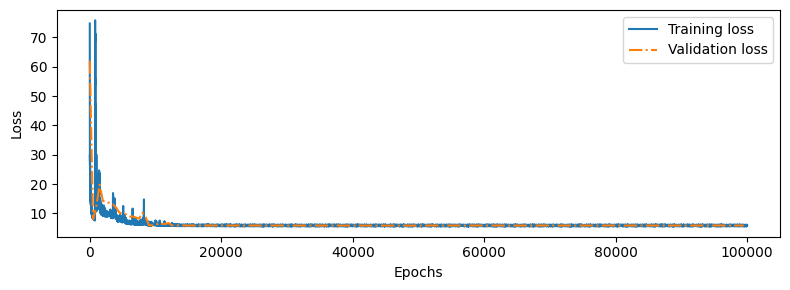

In [46]:
fig, ax1 = plt.subplots(figsize=(8, 3))

# Plot training and validation loss against epochs
ax1.plot(range(TRAIN_STEPS), running, label="Training loss")
ax1.plot(range(TRAIN_STEPS)[::500], val_history, linestyle="-.", label="Validation loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [47]:
# OUT_DIR = "checkpoints/final"
# os.makedirs(OUT_DIR, exist_ok=True)

unwrapped_model = accelerator.unwrap_model(model)

torch.save(
    unwrapped_model.state_dict(),
    os.path.join(OUT_DIR, "model.pt")
)

In [48]:
# !zip -r output.zip checkpoints/ tiny_stories_tokenizer_from_scratch/

## Generate A Sequence

- In this section, we will try to generate text from the trained model in the following :


  - Start from noise sequence (full mask tokens)
  - Predicts the tokens in masked positions by sampling following the probas output
  - Apply a remasking strategy, like remasking the **k** with low probability prediction
  - From the partially denoised sequence, repeat the same process until no `[MASK]` token is left

In [49]:
# load custom tokenizer
DIR_TOKENIZER = "checkpoints/final/tokenizer"
hf_tokenizer = PreTrainedTokenizerFast.from_pretrained(DIR_TOKENIZER)

In [50]:
len(hf_tokenizer)

8000

In [51]:
# class DiffusionTransformer(nn.Module):
#     def __init__(self, cfg):
#         super().__init__()

#         self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
#         self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
#         self.time_emb = nn.Embedding(cfg["diffusion_steps"] + 1, cfg["emb_dim"])
#         self.drop = nn.Dropout(cfg["dropout"])
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=cfg["emb_dim"],
#             nhead=cfg["n_heads"],
#             dim_feedforward=cfg["d_ff"],
#             dropout=cfg["dropout"],
#             activation="gelu",
#             batch_first=True,
#             norm_first=False
#         )

#         self.encoder = nn.TransformerEncoder(encoder_layer , num_layers=cfg["n_layers"])
#         self.ln_f = nn.LayerNorm(cfg["emb_dim"])
#         self.lm_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

#         # Tie weights (optional; common in LMs)
#         self.lm_head.weight = self.tok_emb.weight

#     def forward(self, input_ids, timesteps, attention_mask=None):
#         # input_ids of size [batch_size, seq_length]
#         # timesteps of size [batch_size] integer diffusion step in {1, 2, ...T}
#         batch_size, seq_length = input_ids.shape

#         tok_embeds = self.tok_emb(input_ids)
#         pos_embeds = self.pos_emb(torch.arange(seq_length, device=input_ids.device))
#         x = tok_embeds + pos_embeds # [batch_size, seq_length, emb_dim] emb_dim = d_model

#         # NEW
#         t_emb = self.time_emb(timesteps) # [batch_size, emb_dim]
#         t_emb = t_emb.unsqueeze(1) # [batch_size, 1, emb_dim] to allow broadcasting later
#         x = x + t_emb # [batch_size, seq_length, emb_dim]

#         x = self.drop(x)

#         if attention_mask is None:
#             src_key_padding_mask = None
#         else:
#             src_key_padding_mask = ~attention_mask  # invert: True = PAD tokens which will be ignored

#         x = self.encoder(x, is_causal=False, src_key_padding_mask=src_key_padding_mask) # this is by default False the causal attention mask
#         x = self.ln_f(x)
#         logits = self.lm_head(x) # [batch_size, seq_length, vocab_size]

#         return logits

In [54]:
# load the model
cfg = {
    "vocab_size": len(hf_tokenizer),
    "context_length": 256,
    "emb_dim": 384,
    "n_layers": 6,
    "n_heads": 6,
    "d_ff": 1536, # 4*emb_dim
    "dropout": 0.1,
    "diffusion_steps": 64
}

# cfg = {
#     "vocab_size": len(hf_tokenizer),
#     "context_length": 256,
#     "emb_dim": 512,
#     "n_layers": 10,
#     "n_heads": 8,
#     "d_ff": 2048, # 4*emb_dim
#     "dropout": 0.1,
#     "diffusion_steps": 128
# }
model = DiffusionTransformer(cfg)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state_dict = torch.load(os.path.join(OUT_DIR, "model.pt"))
model.load_state_dict(state_dict)
model = model.to(device)

In [55]:
# compute the number of params
number_params = sum(p.numel() for p in model.parameters())
print(f"{number_params:,} params")

13,842,816 params


In [56]:
full_noise_input = torch.full((1, cfg["context_length"]), MASK_ID, device=device)
full_noise_input

tensor([[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]], device='cuda:0')

In [57]:
user_query = "Once upon a time"
prompt_text = f"<|user|>\n{user_query}.\n<|assistant|>\n<|end|>\n"
prompt_ids = hf_tokenizer.encode(prompt_text, add_special_tokens=True)
length_prompt = len(prompt_ids)
prompt_ids = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0) # shape [1, length_prompt]
prompt_ids, length_prompt

(tensor([[  1,   4, 104, 298, 311, 115, 264,  19, 104,   5, 104,   7, 104,   2]],
        device='cuda:0'),
 14)

In [58]:
full_noise_input[:, :length_prompt] = prompt_ids
context_ex_input = full_noise_input
context_ex_input

tensor([[  1,   4, 104, 298, 311, 115, 264,  19, 104,   5, 104,   7, 104,   2,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
           3,   3,   3,   3,   3,   3,   3,   3,   3

In [ ]:
# we start with a completely masked sequence
full_noise_input = torch.full((1, cfg["context_length"]), MASK_ID, device=device)

# we then append to it the user query
user_query = "Once upon a time"
prompt_text = f"<|user|>\n{user_query}.\n<|assistant|>\n<|end|>\n"
prompt_ids = hf_tokenizer.encode(prompt_text, add_special_tokens=True)
length_prompt = len(prompt_ids)
prompt_ids = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0) # shape [1, length_prompt]

# we then replace the first tokens of the noisy input with the prompt tokens, this will be tthe input at first step s
full_noise_input[:, :length_prompt] = prompt_ids
context_ex_input = full_noise_input

# flag them as fixed tokens (won't be denoised during the inference)
fixed_tokens = torch.zeros((1, cfg["context_length"]), dtype=torch.bool, device=device)
fixed_tokens[:, :length_prompt] = True

# will give the positions of the tokens to be changed, i.e those outside of the prompt text user
update_mask = ~fixed_tokens

In [60]:
model.eval()

x = context_ex_input.clone().to(device)

for s in range(cfg["diffusion_steps"], 0, -1): # reversed T, T-1, ...., 1, 0
    t = torch.tensor([s],dtype=torch.long, device=device)
    with torch.no_grad():
      logits = model(x, timesteps=t)

    topk_vals, topk_idx = torch.topk(logits, k=50, dim=-1)
    filtered = torch.full_like(logits, float("-inf"))
    filtered.scatter_(dim=-1, index=topk_idx, src=topk_vals)
    logits = filtered

    probs = torch.softmax(logits, dim=-1)   # [1, seq_length, vocab_size] as we don't look only at the last token to predict but the whole seq
    flat = probs.view(-1, probs.size(-1)) # [seq_length, vocab_size]

    sampled = torch.multinomial(flat, num_samples=1)  # (seq_length, 1)
    sampled = sampled.squeeze(-1).unsqueeze(0) # [1, seq_length]

    # get the probas associated with the tokens idx that were sampled
    confids = probs.gather(dim=-1, index=sampled.unsqueeze(-1)).squeeze(-1)

    # update only the tokens outside of the prompt user
    x = torch.where(update_mask, sampled, x)
    '''
    at each prediction, we denoise all the masked tokens from the sampled var with the where method

    but we want to iteratively denoise subset of masked tokens and keep some MASKED, until at last step s=1, the tokens
    to be keepen as MASK token are zero : i.e nbr_tokens_kept_masked = 0, so next_ratio is zero

    '''
    next_ratio = (s - 1) / cfg["diffusion_steps"]
    nbr_tokens_kept_masked = int((cfg["context_length"] - length_prompt) * next_ratio)

    # ignore prompt tokens by forcing high prob there
    conf_for_rank = confids.clone()
    conf_for_rank[:, :length_prompt] = float("inf")

    # get the lowest idx token with low probabitlity to remask again
    _, keep_idx = torch.topk(
        conf_for_rank,
        k=nbr_tokens_kept_masked,
        dim=1,
        largest=False
    )
    "important, unlike in MaskGIT, when a token is predicted, it can be masked again  in future steps, so I don't filter them out"
    # replace those token idx with the MASK ID token
    x[0, keep_idx] = MASK_ID


generated_ids = x

In [61]:
generated_text = hf_tokenizer.decode(generated_ids[0].tolist())
print(generated_text)

[BOS]<|user|>
Once upon a time.
<|assistant|>
<|end|>
[EOS] his
 the
 her and said he it.
 and the said
 not it of and on to her the a on it was to a there there, the it of<|user|>.! her there. to. a a for herOnce in time the the.,. " happy a Lily his very was.<|user|>.,,<|user|> in was was.,. she's that.. she and and They was it
,. she had mom a said it a and.. They the
 was,

 her She
 story the in his, was with she. with

 a,,
... and the. was.Once for was He very was. He.. to the
. short, ". He and a. 
's. in
 the and with happy day! and was. They. to with<|assistant|> the were the. had the She, to She<|user|>, a was happy toOnce<|assistant|> the there
 and day.. Lily was. They was had you. 
 was<|end|> a's, it the happy, said's She, was said She the thatOnce. she to. She She she very a with that,. time.Write


In [ ]:
generated_text = hf_tokenizer.decode(generated_ids[0].tolist())
print(generated_text)

[BOS]<|user|>
Once upon a time.
<|assistant|>
<|end|>
[EOS] someBe good andBob, Ben One
 outside


 and had,, had
<|end|> bitter pretend luck of monkey the. when so. it.
 big rock mommy theTom short sweater some until two. selfish runningid..,
 very,. pretty could and draw ventured her,. idea and them
 and Ben smile, Timmy worked Timmy had, wait but from happy a put gives be a to himself!œI
 a but and fruit a hurt just butterflies world and dog The time. muffin waited some were day there Robbie It youvest it tree<|user|> little girl for too named crystal fenceWhen the he every
 a She noise please had.
 and
 She a was helpless each each Tom wanted is sillyu it wanted stars for and

 short, them place my sorry woke
 grateful were " too and her sun very the<|end|> ride open
 and Her to took She she Sarah ran a WeI
. who every never need to She field
 has little fly delight flowers. and new So she his,! it said. mud the." tree agreed all<|end|> bucket and and day the that is You, read park

In [62]:
cfg

{'vocab_size': 8000,
 'context_length': 256,
 'emb_dim': 384,
 'n_layers': 6,
 'n_heads': 6,
 'd_ff': 1536,
 'dropout': 0.1,
 'diffusion_steps': 64}

In [63]:
@torch.no_grad()
def diffusion_generate(
    model,
    tokenizer,
    prompt_text: str,
    max_new_tokens: int = 128,
    diffusion_steps: int = 64,
    temperature: float = 1.0,
    top_k: int = 0,
    record_steps: bool = True,
):
    model.eval()
    device = next(model.parameters()).device

    prompt_ids = tokenizer.encode(prompt_text, add_special_tokens=True)
    prompt_ids = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0)  # [1, Lp]

    Lp = prompt_ids.size(1)
    L = min(cfg["context_length"], Lp + max_new_tokens)
    gen_len = L - Lp

    x = torch.full((1, L), MASK_ID, dtype=torch.long, device=device)
    x[:, :Lp] = prompt_ids[:, :Lp]

    fixed = torch.zeros((1, L), dtype=torch.bool, device=device)
    fixed[:, :Lp] = True

    attention_mask = torch.ones((1, L), dtype=torch.bool, device=device)

    frames = []

    def sample_from_logits(logits):
        if temperature != 1.0:
            logits = logits / temperature

        if top_k and top_k > 0:
            topk_vals, topk_idx = torch.topk(logits, k=top_k, dim=-1)
            filtered = torch.full_like(logits, float("-inf"))
            filtered.scatter_(-1, topk_idx, topk_vals)
            logits = filtered

        probs = F.softmax(logits, dim=-1)
        flat = probs.view(-1, probs.size(-1))
        sampled = torch.multinomial(flat, num_samples=1).view(1, L)
        sampled_prob = probs.gather(-1, sampled.unsqueeze(-1)).squeeze(-1)  # [1,L]
        return sampled, sampled_prob

    for s in range(diffusion_steps, 0, -1):
        t = torch.tensor([s], device=device, dtype=torch.long)
        logits = model(x, timesteps=t, attention_mask=attention_mask)
        sampled, conf = sample_from_logits(logits)

        update_pos = ~fixed
        x[update_pos] = sampled[update_pos]

        next_ratio = float(s - 1) / float(diffusion_steps)
        target_masks = int(math.ceil(gen_len * next_ratio))

        gen_positions = torch.arange(L, device=device) >= Lp
        candidates = gen_positions & (~fixed[0])
        cand_idx = torch.where(candidates)[0]

        if target_masks > 0 and cand_idx.numel() > 0:
            cand_conf = conf[0, cand_idx]
            k = min(target_masks, cand_idx.numel())
            _, low_idx = torch.topk(cand_conf, k=k, largest=False)
            remask_positions = cand_idx[low_idx]
            x[0, remask_positions] = MASK_ID

        if record_steps:
            decoded = tokenizer.decode(x[0].tolist())
            decoded = decoded.replace("[MASK]", "█")
            frames.append((s, decoded))

    final = tokenizer.decode(x[0].tolist())
    model.train()
    return final, frames

def chat_prompt(user_msg: str, system_msg: str = None) -> str:
    parts = []
    if system_msg:
        parts.append(f"<|system|>\n{system_msg}\n")
    parts.append(f"<|user|>\n{user_msg}\n")
    parts.append("<|assistant|>\n")
    return "".join(parts)

TEST_USER_PROMPT = "Once upon a time"
prompt_text = chat_prompt(TEST_USER_PROMPT)

final_text, frames = diffusion_generate(
    model=accelerator.unwrap_model(model),
    tokenizer=hf_tokenizer,
    prompt_text=prompt_text,
    max_new_tokens=128,
    diffusion_steps=cfg["diffusion_steps"],
    temperature=1.0,
    top_k=50,
    record_steps=True,
)

print("Final decoded (raw):\n")
print(final_text[:1000])
print("\nRecorded frames:", len(frames))

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Final decoded (raw):

[BOS]<|user|>
Once upon a time
<|assistant|>
[EOS] not
 and
.<|user|>
 very it
 said it you the They a it that mom happy

 and the were. the,, a so was a his He was 
 day the that
 and it of and
 and she " and.. a a ". the so
 and happy said. and's was,

 and to She. his She so a. they a. and was Lily was " and Lily theWrite. her and was day so<|assistant|>. a was and the to the happy he the with the
, 
 was. she. you she her They
 a happy and a very. a

Recorded frames: 64
